In [ ]:
############# Explore Beaufort Shelfbreak Air Humidity ################
# The purpose of this script is to explore the air humidity in ERA5 data
# in the region of the Beaufort shelfbreak jet that we are analyzing. 
# If appropriate, an idealized curve will be fit to the data to be used
# as input into the ROMS-BUDGELL idealized model. 
#
# Notes:
# -
#
######################################################################

In [1]:
# Load in the packages
import xarray as xr
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import numpy as np
from netCDF4 import Dataset
import datetime
from datetime import datetime
import matplotlib.dates as mdates
import pandas as pd
import xroms
from matplotlib import ticker
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") 
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

from xhistogram.xarray import histogram

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Load in the air temperature data
era5_air_temp = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/External_data/ERA5_data/temp_2m_era5_2017_2024.nc')
era5_air_temp

<xarray.Dataset> Size: 454MB
Dimensions:     (valid_time: 70128, longitude: 77, latitude: 21)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 616B -156.0 -155.8 -155.5 ... -137.2 -137.0
  * latitude    (latitude) float64 168B 73.0 72.75 72.5 ... 68.5 68.25 68.0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 454MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Aug 07 08:21:21 2025: cdo mergetime temp_2m_...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

In [4]:
era5_dew.d2m

<xarray.DataArray 'd2m' (valid_time: 70128, latitude: 21, longitude: 77)> Size: 454MB
[113396976 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 616B -156.0 -155.8 -155.5 ... -137.2 -137.0
  * latitude    (latitude) float64 168B 73.0 72.75 72.5 ... 68.5 68.25 68.0
Attributes: (12/32)
    standard_name:                            unknown
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    GRIB_paramId:                             168
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1617
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    GRIB_surface:                             0.0

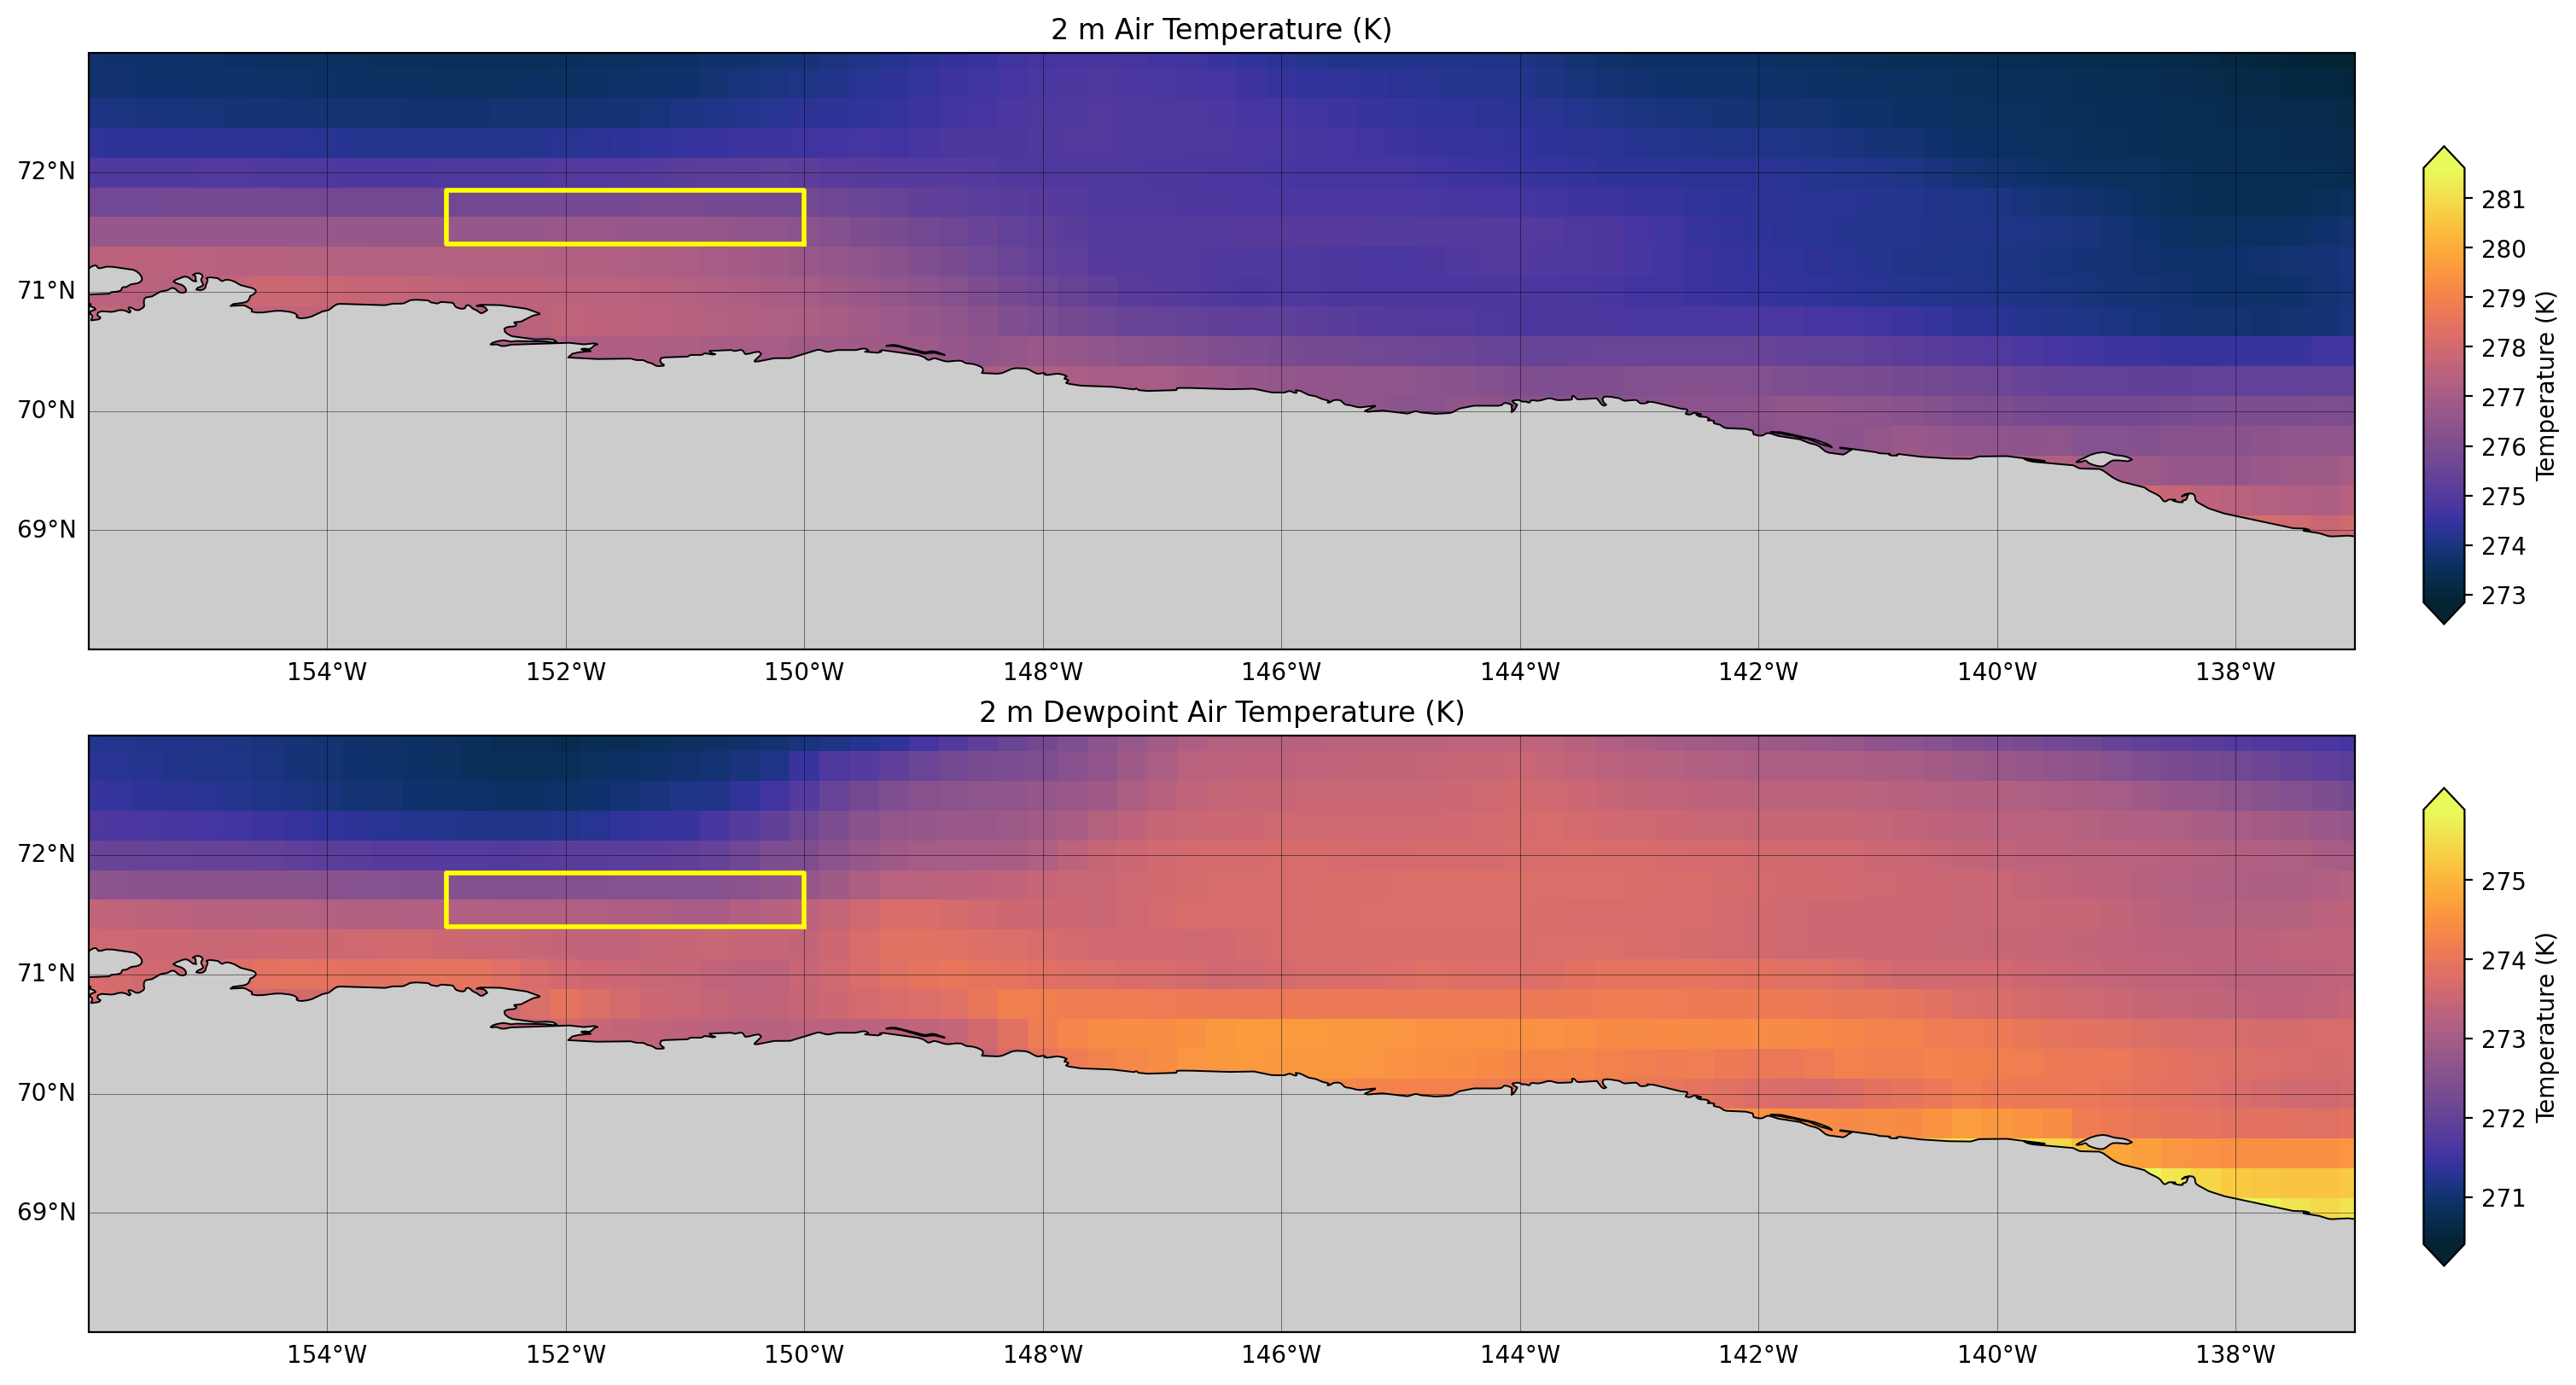

In [5]:
# Plot the region that the data covers
# Box 1

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)

# Make the figure 
fig, ax = plt.subplots(2, 1, figsize=(16,8), dpi=200,
                       constrained_layout=True, 
                       subplot_kw={'projection': crs})

# Plot surface u at 2019-09-01 
m1 = era5_air_temp.t2m.sel(valid_time='2019-09-15 00:00:00', method='nearest').plot(
    x='longitude', y='latitude',
    ax=ax[0],
    cmap=cmo.thermal, transform=ccrs.PlateCarree(),
    add_colorbar=False, facecolor="gray",
)
ax[0].set_title('2 m Air Temperature (K)')
# Make a colorbar 
cbar_ax1 = fig.add_axes([0.94,0.55,0.015,0.35])
fig.colorbar(m1,ax=ax,extend='both',
             label='Temperature (K)',
             pad=0.03, cax=cbar_ax1)

# Plot surface u at 2019-09-15
m2 = era5_dew.d2m.sel(valid_time='2019-09-15 00:00:00', method='nearest').plot(
    x='longitude', y='latitude',
    ax=ax[1],
    cmap=cmo.thermal, transform=ccrs.PlateCarree(),
    add_colorbar=False, facecolor="gray",
)
ax[1].set_title('2 m Dewpoint Air Temperature (K)')
# Make a colorbar 
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(m2,ax=ax,extend='both',
             label='Temperature (K)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set extent and map features
    ax[r].set_extent([-156,-137,68, 73],ccrs.PlateCarree())
    ax[r].add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                facecolor='0.8'), linewidth=.7)
    ax[r].coastlines(resolution='10m', linewidth=.7)

    # Add bathymetry for the domain
    #ax[r].contour(grid.lon_rho, grid.lat_rho, grid.h, levels=lev_bathy, colors='dimgrey')

    gl = ax[r].gridlines(crs=ccrs.PlateCarree(), 
                    draw_labels=True, 
                    x_inline=False, y_inline=False, 
                    linewidth=0.33, color='k',alpha=0.5)
    gl.right_labels = gl.top_labels = False
    gl.xlocator = ticker.FixedLocator([-156, -154, -152, -150,-148,-146,-144,-142, -140, -138])
    gl.xlabel_style = {'rotation': 0, 'ha': 'center'}

# Pick a region to analyze 
# Box 1
box_min_lon_01 = -150
box_max_lon_01 = -153
box_min_lat_01 = 71.4
box_max_lat_01 = 71.85
# Plot Box 1
ax[0].plot([box_min_lon_01, box_max_lon_01, box_max_lon_01, box_min_lon_01, box_min_lon_01],
        [box_min_lat_01, box_min_lat_01, box_max_lat_01, box_max_lat_01, box_min_lat_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_lon_01, box_max_lon_01, box_max_lon_01, box_min_lon_01, box_min_lon_01],
        [box_min_lat_01, box_min_lat_01, box_max_lat_01, box_max_lat_01, box_min_lat_01],
        color='yellow', linestyle='-', linewidth=2)

fig.canvas.draw()
 


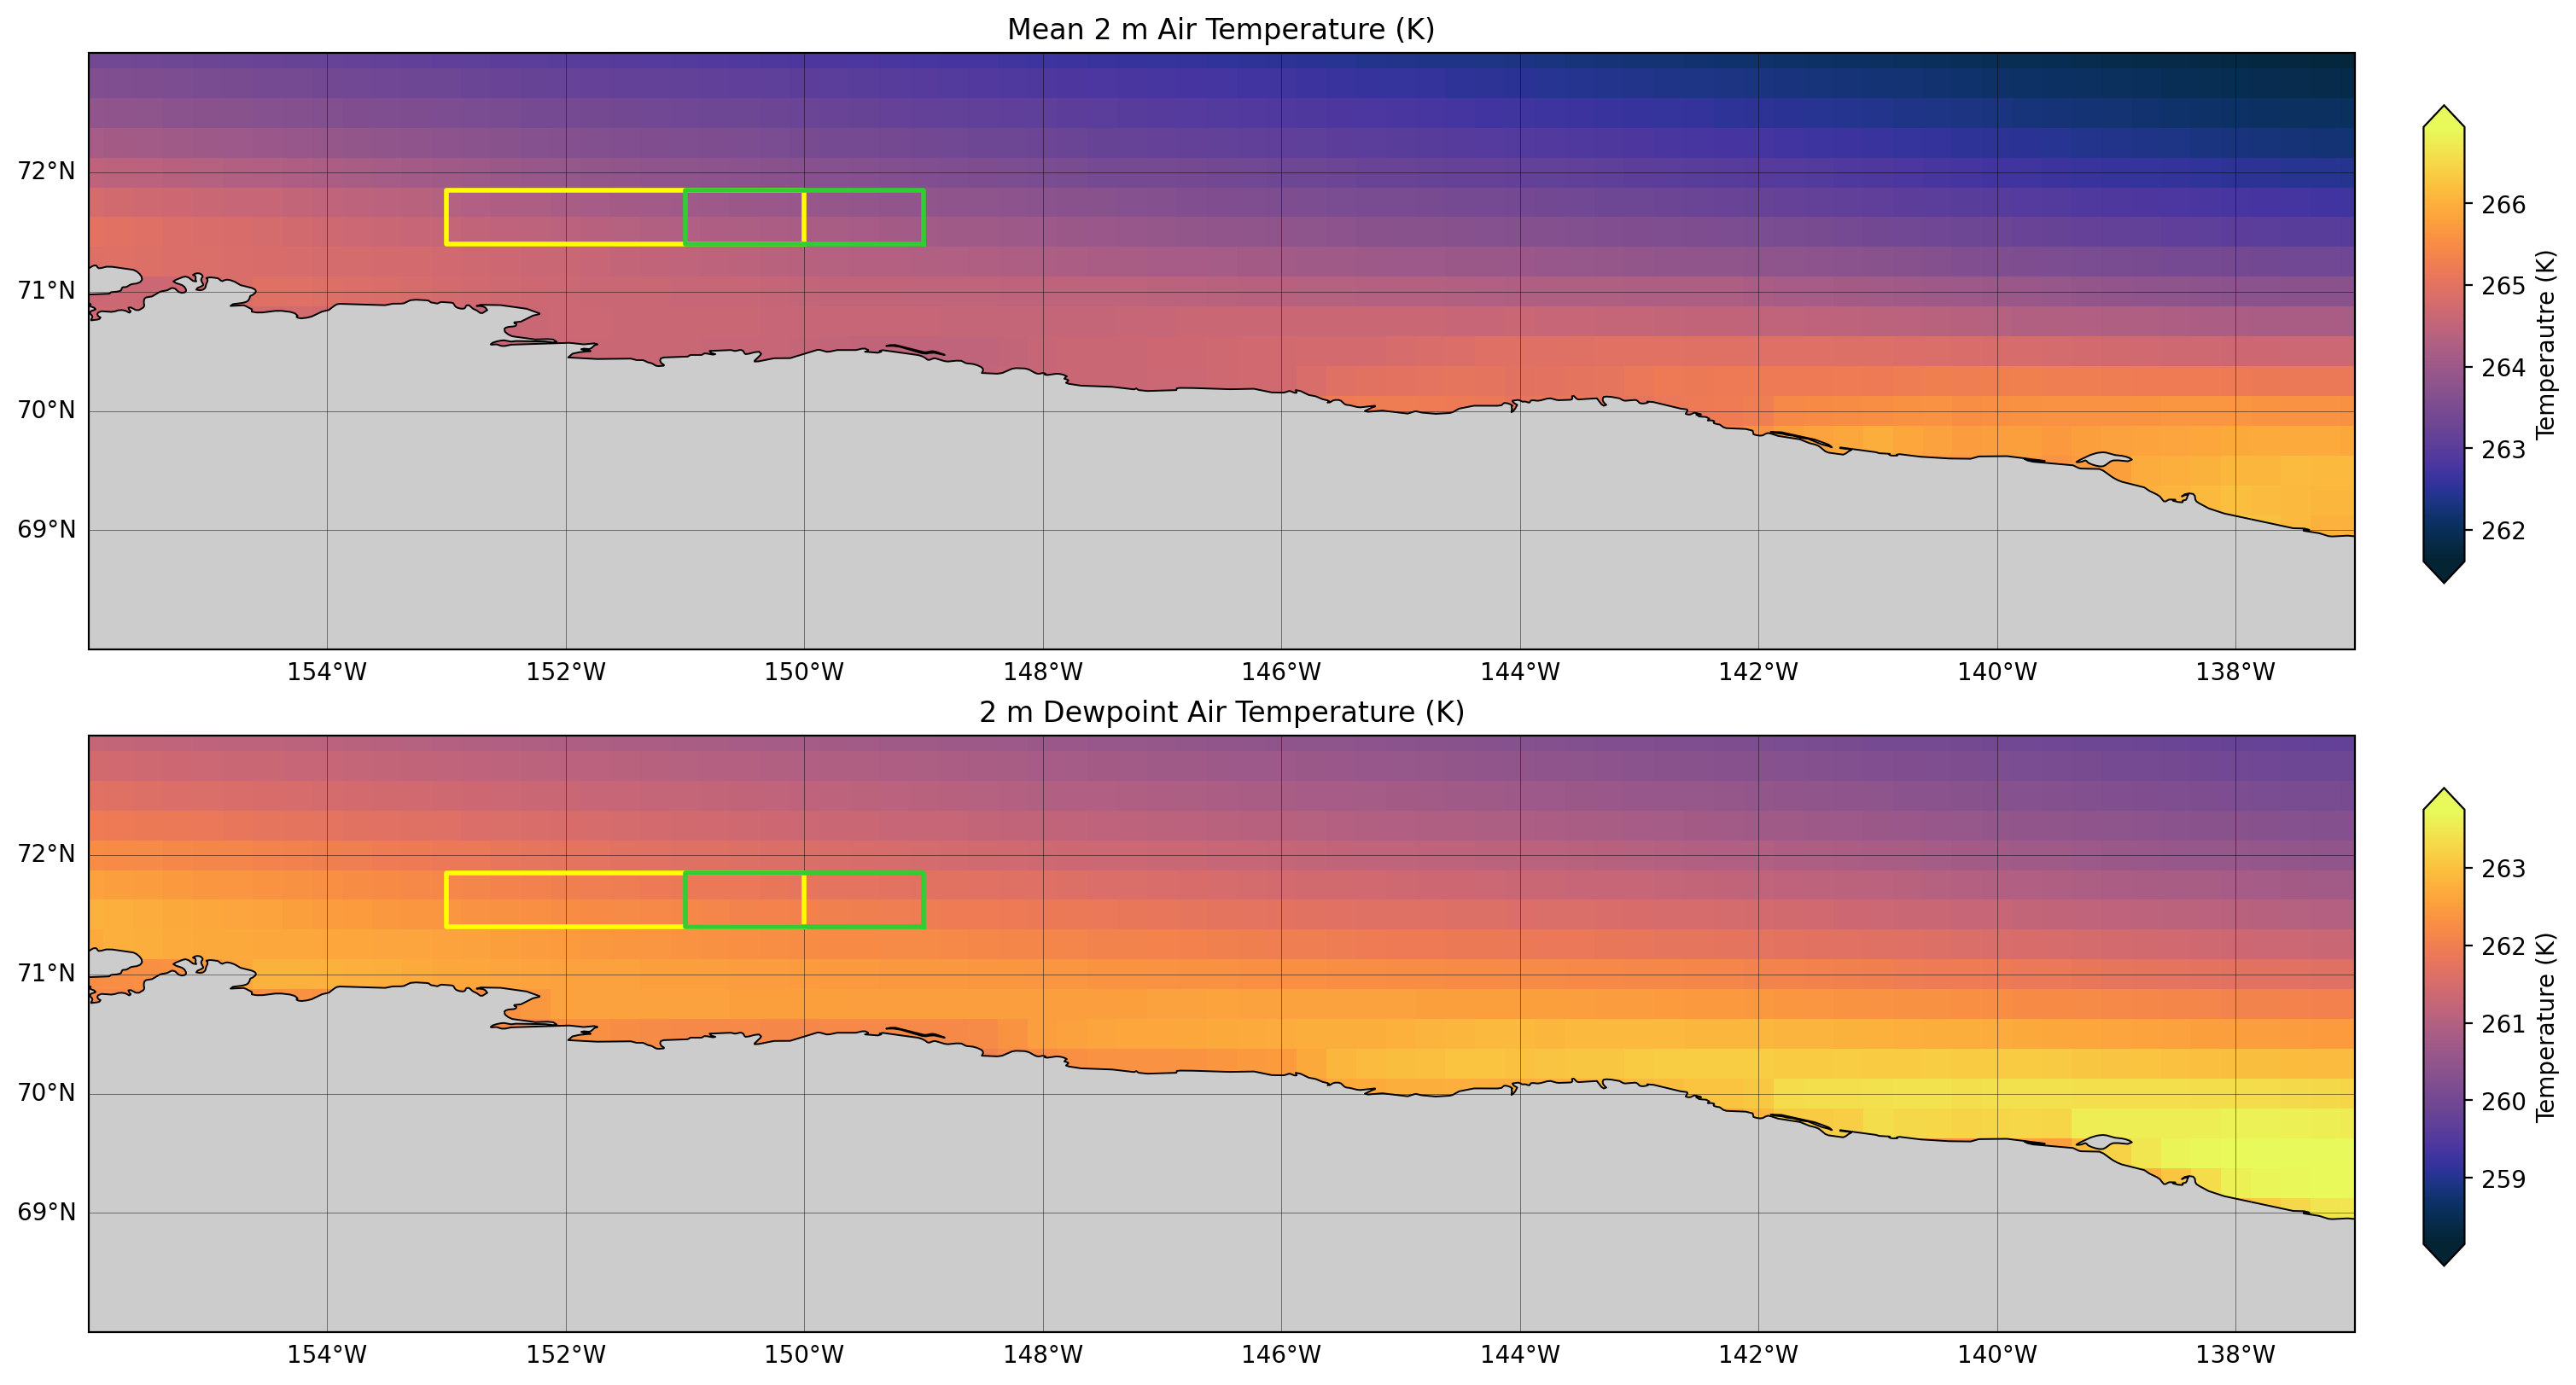

In [6]:
# Plot means
# Put both boxes

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)

# Make the figure 
fig, ax = plt.subplots(2, 1, figsize=(16,8), dpi=200,
                       constrained_layout=True, 
                       subplot_kw={'projection': crs})

# Plot surface u at 2019-09-01 
m1 = era5_air_temp.t2m.mean(dim='valid_time').plot(
    x='longitude', y='latitude',
    ax=ax[0],
    cmap=cmo.thermal, transform=ccrs.PlateCarree(),
    add_colorbar=False, facecolor="gray",
)
ax[0].set_title('Mean 2 m Air Temperature (K)')

# Plot surface u at 2019-09-15
m2 = era5_dew.d2m.mean(dim='valid_time').plot(
    x='longitude', y='latitude',
    ax=ax[1],
    cmap=cmo.thermal, transform=ccrs.PlateCarree(),
    add_colorbar=False, facecolor="gray",
)
ax[1].set_title('2 m Dewpoint Air Temperature (K)')


# Make a colorbar for each plot
# Longwave
cbar_ax1 = fig.add_axes([0.94,0.58,0.015,0.35])
fig.colorbar(m1,ax=ax,extend='both',
             label='Temperautre (K)',
             pad=0.03, cax=cbar_ax1)
# Shortwave
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(m2,ax=ax,extend='both',
             label='Temperature (K)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set extent and map features
    ax[r].set_extent([-156,-137,68, 73],ccrs.PlateCarree())
    ax[r].add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                facecolor='0.8'), linewidth=.7)
    ax[r].coastlines(resolution='10m', linewidth=.7)

    # Add bathymetry for the domain
    #ax[r].contour(grid.lon_rho, grid.lat_rho, grid.h, levels=lev_bathy, colors='dimgrey')

    gl = ax[r].gridlines(crs=ccrs.PlateCarree(), 
                    draw_labels=True, 
                    x_inline=False, y_inline=False, 
                    linewidth=0.33, color='k',alpha=0.5)
    gl.right_labels = gl.top_labels = False
    gl.xlocator = ticker.FixedLocator([-156, -154, -152, -150,-148,-146,-144,-142, -140, -138])
    gl.xlabel_style = {'rotation': 0, 'ha': 'center'}

# Pick a region to analyze 
# Box 1
box_min_lon_01 = -150
box_max_lon_01 = -153
box_min_lat_01 = 71.4
box_max_lat_01 = 71.85
# Plot Box 1
ax[0].plot([box_min_lon_01, box_max_lon_01, box_max_lon_01, box_min_lon_01, box_min_lon_01],
        [box_min_lat_01, box_min_lat_01, box_max_lat_01, box_max_lat_01, box_min_lat_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_lon_01, box_max_lon_01, box_max_lon_01, box_min_lon_01, box_min_lon_01],
        [box_min_lat_01, box_min_lat_01, box_max_lat_01, box_max_lat_01, box_min_lat_01],
        color='yellow', linestyle='-', linewidth=2)
# Box 2
box_min_lon_02 = -149
box_max_lon_02 = -151
box_min_lat_02 = 71.4
box_max_lat_02 = 71.85
# Plot Box 2
ax[0].plot([box_min_lon_02, box_max_lon_02, box_max_lon_02, box_min_lon_02, box_min_lon_02],
        [box_min_lat_02, box_min_lat_02, box_max_lat_02, box_max_lat_02, box_min_lat_02],
        color='limegreen', linestyle='-', linewidth=2)
ax[1].plot([box_min_lon_02, box_max_lon_02, box_max_lon_02, box_min_lon_02, box_min_lon_02],
        [box_min_lat_02, box_min_lat_02, box_max_lat_02, box_max_lat_02, box_min_lat_02],
        color='limegreen', linestyle='-', linewidth=2)

fig.canvas.draw()

In [7]:
print('ERA5 air temp min: ', era5_air_temp.t2m.min().values)
print('ERA5 air temp max: ', era5_air_temp.t2m.max().values)
print('ERA5 air temp mean: ', era5_air_temp.t2m.mean().values)
print('ERA5 air temp stddev: ', era5_air_temp.t2m.std().values)
print('ERA5 air dewpoint temp min: ', era5_dew.d2m.min().values)
print('ERA5 air dewpoint temp max: ', era5_dew.d2m.max().values)
print('ERA5 air dewpoint temp mean: ', era5_dew.d2m.mean().values)
print('ERA5 air dewpoint temp stddev: ', era5_dew.d2m.std().values)

ERA5 air temp min:  221.46794
ERA5 air temp max:  304.6587
ERA5 air temp mean:  264.15115
ERA5 air temp stddev:  12.7454405
ERA5 air dewpoint temp min:  217.24173
ERA5 air dewpoint temp max:  294.34424
ERA5 air dewpoint temp mean:  261.51605
ERA5 air dewpoint temp stddev:  12.974671


In [8]:
# Trim to our boxes
# Convert to 360 bassed lat/lon
# Box 1
box_min_lon_01_360 = box_max_lon_01 + 360 
box_max_lon_01_360 = box_min_lon_01 + 360 
# Box 2
box_min_lon_02_360 = box_max_lon_02 + 360 
box_max_lon_02_360 = box_min_lon_02 + 360 


print('Box 1 Bounds:')
print('min_lon: ', str(box_min_lon_01) + ' (W) or ' + str(box_min_lon_01_360) + ' (0 - 360)')
print('max_lon: ', str(box_max_lon_01) + ' (W) or ' + str(box_max_lon_01_360) + ' (0 - 360)')
print('min_lat: ', box_min_lat_01)
print('max_lat: ', box_max_lat_01)
print('Box 2 Bounds:')
print('min_lon: ', str(box_min_lon_02) + ' (W) or ' + str(box_min_lon_02_360) + ' (0 - 360)')
print('max_lon: ', str(box_max_lon_02) + ' (W) or ' + str(box_max_lon_02_360) + ' (0 - 360)')
print('min_lat: ', box_min_lat_02)
print('max_lat: ', box_max_lat_02)

# Get the data in our two boxes
# Box 1
air_temp_reg1 = era5_air_temp.t2m.sel(longitude=slice(box_max_lon_01, box_min_lon_01), latitude=slice(72, 71))
air_dew_reg1 = era5_dew.d2m.sel(longitude=slice(box_max_lon_01, box_min_lon_01), latitude=slice(72, 71))
# Box 2
air_temp_reg2 = era5_air_temp.t2m.sel(longitude=slice(box_max_lon_02, box_min_lon_02), latitude=slice(72, 71))
air_dew_reg2 = era5_dew.d2m.sel(longitude=slice(box_max_lon_02, box_min_lon_02), latitude=slice(72, 71))

Box 1 Bounds:
min_lon:  -150 (W) or 207 (0 - 360)
max_lon:  -153 (W) or 210 (0 - 360)
min_lat:  71.4
max_lat:  71.85
Box 2 Bounds:
min_lon:  -149 (W) or 209 (0 - 360)
max_lon:  -151 (W) or 211 (0 - 360)
min_lat:  71.4
max_lat:  71.85


In [9]:
air_dew_reg1

<xarray.DataArray 'd2m' (valid_time: 70128, latitude: 5, longitude: 13)> Size: 18MB
array([[[255.51416, 255.45947, ..., 254.93994, 254.8872 ],
        [256.65283, 256.5962 , ..., 255.90479, 255.85205],
        ...,
        [257.49268, 257.4458 , ..., 256.5083 , 256.42822],
        [256.99854, 256.96924, ..., 256.74268, 256.68213]],

       [[255.83293, 255.73723, ..., 254.89348, 254.80754],
        [257.07318, 257.01654, ..., 256.00287, 255.91692],
        ...,
        [257.75873, 257.73724, ..., 256.96185, 256.83685],
        [257.4013 , 257.372  , ..., 257.2724 , 257.21576]],

       ...,

       [[241.37444, 241.351  , ..., 241.94865, 241.95647],
        [241.86467, 241.87248, ..., 241.95256, 241.96037],
        ...,
        [243.04436, 243.01897, ..., 242.8217 , 242.81975],
        [243.48186, 243.44475, ..., 243.76115, 243.7006 ]],

       [[241.29231, 241.27278, ..., 241.91731, 241.92513],
        [241.79036, 241.80403, ..., 241.9134 , 241.91927],
        ...,
        [243.0052 , 242.97786, ..., 242.7552 , 242.74934],
        [243.44661, 243.4056 , ..., 243.52473, 243.5345 ]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 104B -153.0 -152.8 -152.5 ... -150.2 -150.0
  * latitude    (latitude) float64 40B 72.0 71.75 71.5 71.25 71.0
Attributes: (12/32)
    standard_name:                            unknown
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    GRIB_paramId:                             168
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1617
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    GRIB_surface:                             0.0

In [10]:
# Take the average over space but keep changes in time 
# Box 1 
air_temp_reg1_avg = air_temp_reg1.mean(dim=['latitude', 'longitude'])
air_dew_reg1_avg = air_dew_reg1.mean(dim=['latitude', 'longitude'])
# Box 2 
air_temp_reg2_avg = air_temp_reg2.mean(dim=['latitude', 'longitude'])
air_dew_reg2_avg = air_dew_reg2.mean(dim=['latitude', 'longitude'])

Text(0.5, 0, 'Year')

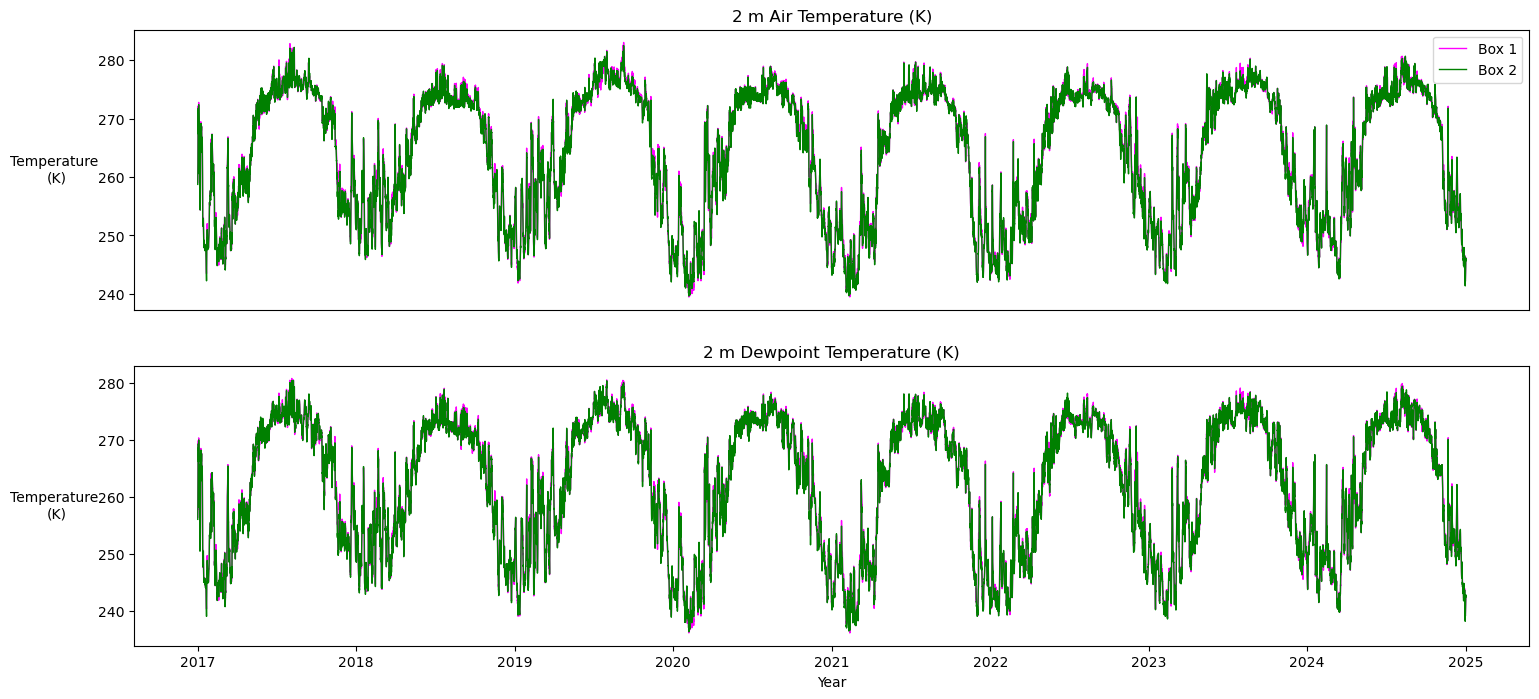

In [11]:
# Plot time series for these two regions (one panel for longwave
# and another for shortwave)

# Make the figure
fig, ax = plt.subplots(2, 1, figsize=(18,8))

# Longwave
ax[0].plot(era5_air_temp.valid_time, air_temp_reg1_avg, color='magenta', linewidth=1, label='Box 1')
ax[0].plot(era5_air_temp.valid_time, air_temp_reg2_avg, color='green', linewidth=1, label='Box 2')
ax[0].set_title('2 m Air Temperature (K)')
ax[0].set_ylabel('Temperature \n(K)', rotation=0, va='center', labelpad=30)
ax[0].xaxis.set_visible(False)
ax[0].legend()

# Shortwave
ax[1].plot(era5_dew.valid_time, air_dew_reg1_avg, color='magenta', linewidth=1, label='Box 1')
ax[1].plot(era5_dew.valid_time, air_dew_reg2_avg, color='green', linewidth=1, label='Box 2')
ax[1].set_title('2 m Dewpoint Temperature (K)')
ax[1].set_ylabel('Temperature \n(K)', rotation=0, va='center', labelpad=30)
ax[1].set_xlabel('Year')

In [12]:
# Make a version of the plot that has the average value
# for each day of each based on all of these years

# group by hour of day of year to rpeserve that frequency

# Box 1
air_temp_reg1_avg_doy_hrly = air_temp_reg1_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')
air_dew_reg1_avg_doy_hrly = air_dew_reg1_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')
# Box 2
air_temp_reg2_avg_doy_hrly = air_temp_reg2_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')
air_dew_reg2_avg_doy_hrly = air_dew_reg2_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')

In [13]:
# Reshape to be time series
# Dumb way would be to loop and we could just do that...
# Yup takes no time do the dumb way
# Box 1 
air_temp_reg1_avg_doy_hrly2 = np.empty((len(air_temp_reg1_avg_doy_hrly[:,0])*len(air_temp_reg1_avg_doy_hrly[0,:])))
air_dew_reg1_avg_doy_hrly2 = np.empty((len(air_dew_reg1_avg_doy_hrly[:,0])*len(air_dew_reg1_avg_doy_hrly[0,:])))
# Box 2
air_temp_reg2_avg_doy_hrly2 = np.empty((len(air_temp_reg2_avg_doy_hrly[:,0])*len(air_temp_reg2_avg_doy_hrly[0,:])))
air_dew_reg2_avg_doy_hrly2 = np.empty((len(air_dew_reg2_avg_doy_hrly[:,0])*len(air_dew_reg2_avg_doy_hrly[0,:])))

# Set the count for looping
count = 0

# Loop through day of year
for d in range(len(air_temp_reg1_avg_doy_hrly[:,0])):
    # Set the indices 
    start = count
    end = start + 24
    #print('start: ', start)
    #print('end: ', end)
 
    # Save this to the array
    # Box 1
    air_temp_reg1_avg_doy_hrly2[start:end] = air_temp_reg1_avg_doy_hrly[d,:]
    air_dew_reg1_avg_doy_hrly2[start:end] = air_dew_reg1_avg_doy_hrly[d,:]
    # Box 2
    air_temp_reg2_avg_doy_hrly2[start:end] = air_temp_reg2_avg_doy_hrly[d,:]
    air_dew_reg2_avg_doy_hrly2[start:end] = air_dew_reg2_avg_doy_hrly[d,:]

    # Increase the count
    #print('count before: ', count)
    count = count + 24
    #print('count after: ', count)

Text(0.5, 0, 'Day & Hour of Year')

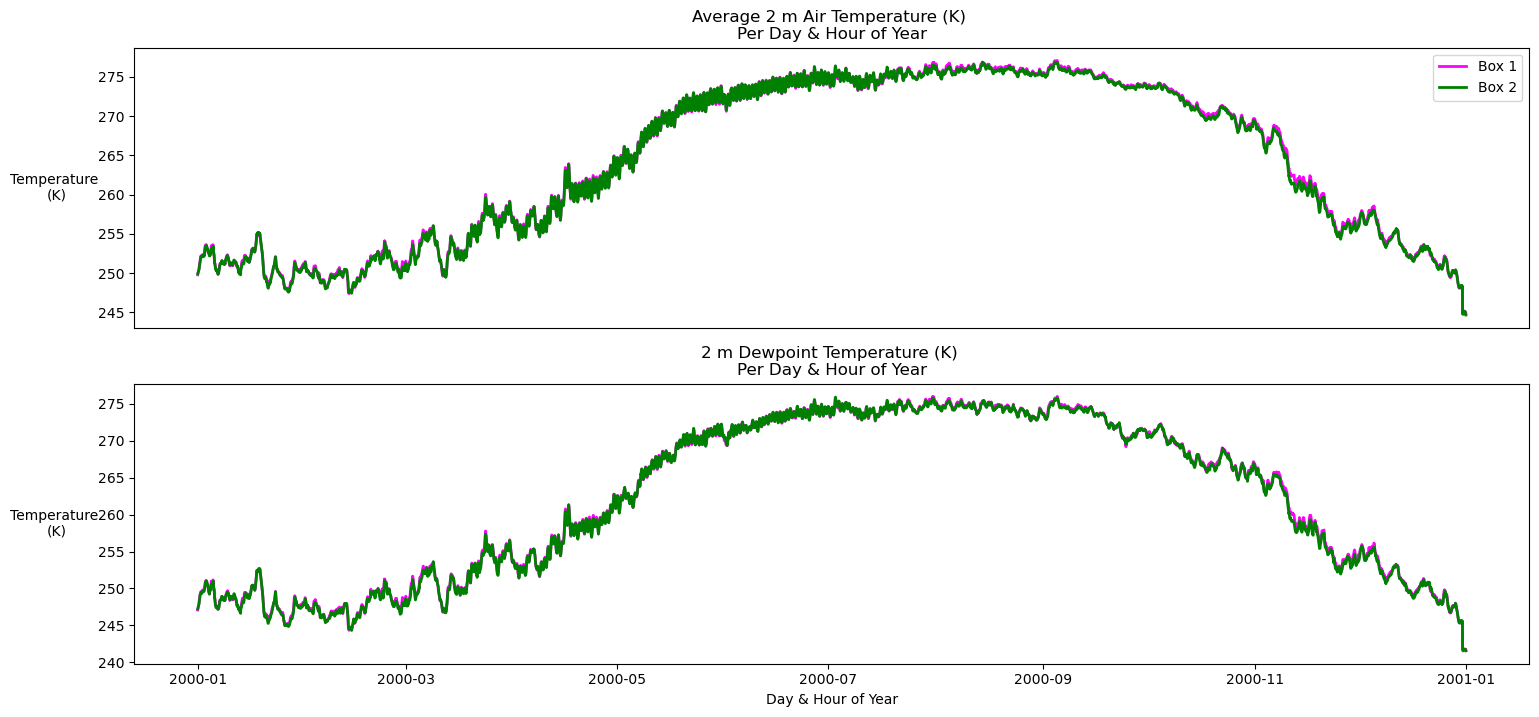

In [14]:
# Make day of year array
day_of_year = np.arange(1, 367, 1)

# Make new time index 
doy_w_hour = np.arange(1, 8785, 1)
hourly_datetimes = pd.date_range(start='2000-01-01', periods=366*24, freq='H')

# Make the figure
fig, ax = plt.subplots(2, 1, figsize=(18,8))

# Longwave
ax[0].plot(hourly_datetimes, air_temp_reg1_avg_doy_hrly2, color='magenta', linewidth=2, label='Box 1')
ax[0].plot(hourly_datetimes, air_temp_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax[0].set_title('Average 2 m Air Temperature (K) \nPer Day & Hour of Year')
ax[0].set_ylabel('Temperature \n(K)', rotation=0, va='center', labelpad=30)
ax[0].xaxis.set_visible(False)
ax[0].legend()

# Shortwave
ax[1].plot(hourly_datetimes, air_dew_reg1_avg_doy_hrly2, color='magenta', linewidth=2, label='Box 1')
ax[1].plot(hourly_datetimes, air_dew_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax[1].set_title('2 m Dewpoint Temperature (K) \nPer Day & Hour of Year')
ax[1].set_ylabel('Temperature \n(K)', rotation=0, va='center', labelpad=30)
ax[1].set_xlabel('Day & Hour of Year')

Text(0.5, 0, 'Day & Hour of Year')

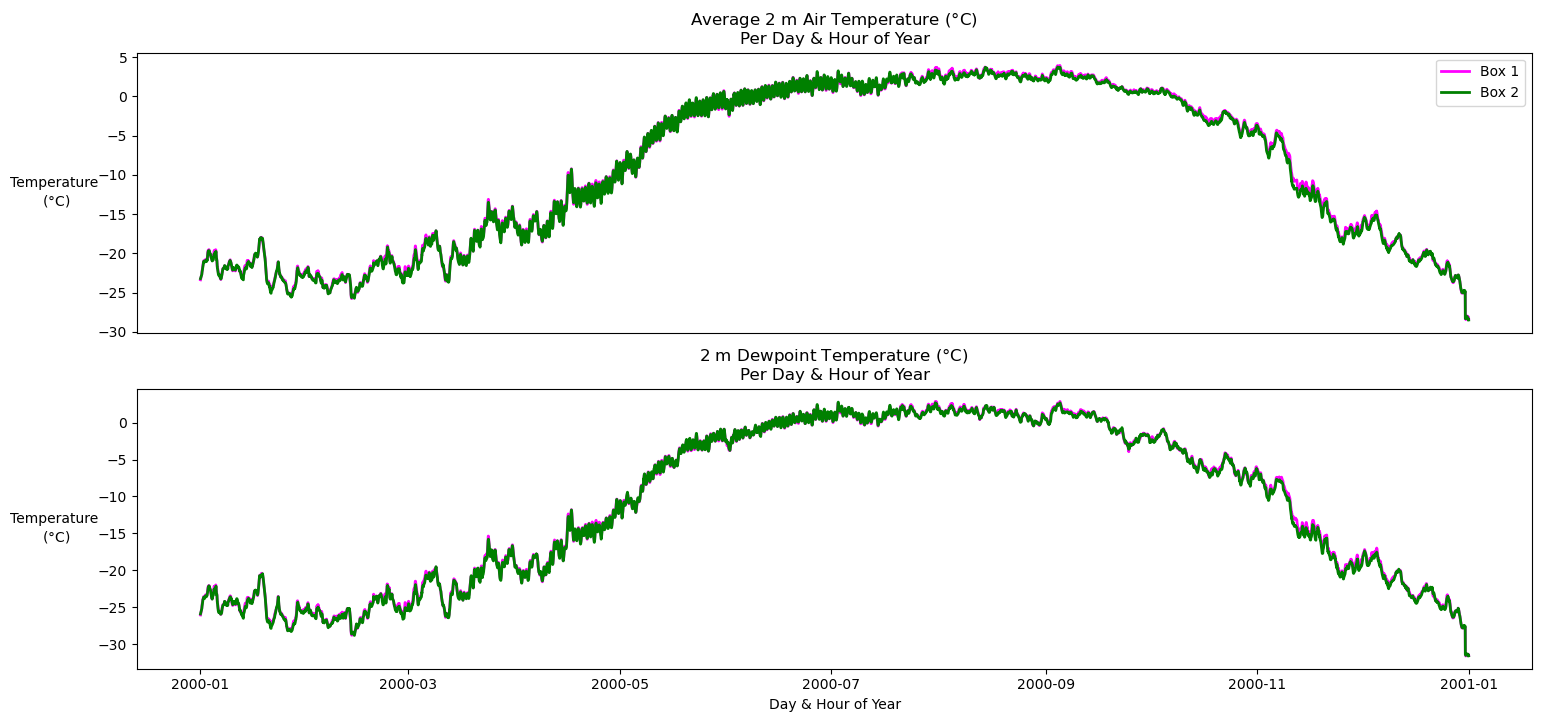

In [20]:
# Plot again but in Celsius
# Make the figure
fig, ax = plt.subplots(2, 1, figsize=(18,8))

# Longwave
ax[0].plot(hourly_datetimes, air_temp_reg1_avg_doy_hrly2-273.15, color='magenta', linewidth=2, label='Box 1')
ax[0].plot(hourly_datetimes, air_temp_reg2_avg_doy_hrly2-273.15, color='green', linewidth=2, label='Box 2')
ax[0].set_title('Average 2 m Air Temperature ($\degree$C) \nPer Day & Hour of Year')
ax[0].set_ylabel('Temperature \n($\degree$C)', rotation=0, va='center', labelpad=30)
ax[0].xaxis.set_visible(False)
ax[0].legend()

# Shortwave
ax[1].plot(hourly_datetimes, air_dew_reg1_avg_doy_hrly2-273.15, color='magenta', linewidth=2, label='Box 1')
ax[1].plot(hourly_datetimes, air_dew_reg2_avg_doy_hrly2-273.15, color='green', linewidth=2, label='Box 2')
ax[1].set_title('2 m Dewpoint Temperature ($\degree$C) \nPer Day & Hour of Year')
ax[1].set_ylabel('Temperature \n($\degree$C)', rotation=0, va='center', labelpad=30)
ax[1].set_xlabel('Day & Hour of Year')

Text(0.5, 0, 'Day & Hour of Year')

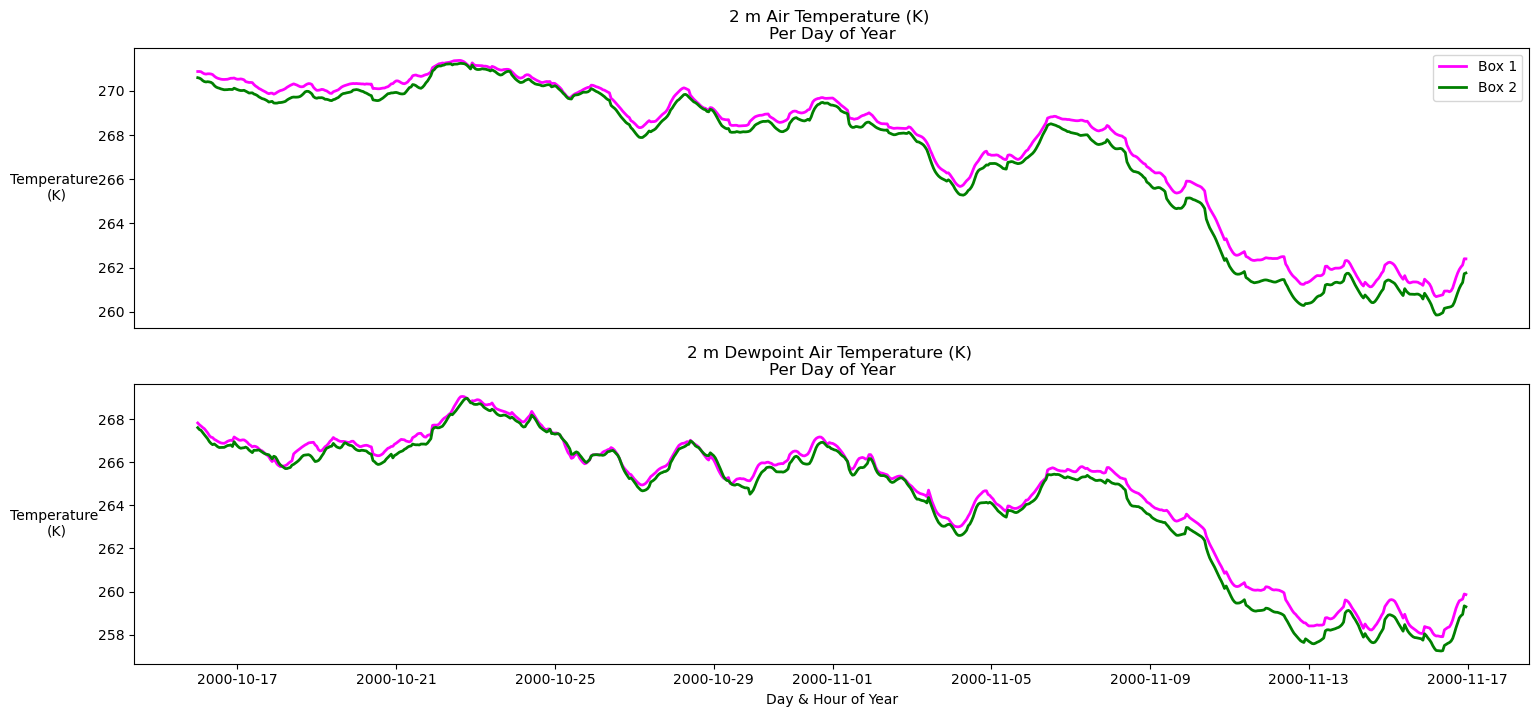

In [21]:
# Trim to just the period we want
# Plot the values around freeze-up which is mid-October to mid-November (ish)
# September 15 - October 15 = days 289 - 320 (leap year)

# Make the figure
fig, ax = plt.subplots(2, 1, figsize=(18,8))

# Longwave
ax[0].plot(hourly_datetimes[289*24:321*24], air_temp_reg1_avg_doy_hrly2[289*24:321*24], color='magenta', linewidth=2, label='Box 1')
ax[0].plot(hourly_datetimes[289*24:321*24], air_temp_reg2_avg_doy_hrly2[289*24:321*24], color='green', linewidth=2, label='Box 2')
ax[0].set_title('2 m Air Temperature (K) \nPer Day of Year')
ax[0].set_ylabel('Temperature \n(K)', rotation=0, va='center', labelpad=30)
ax[0].xaxis.set_visible(False)
ax[0].legend()

# Shortwave
ax[1].plot(hourly_datetimes[289*24:321*24], air_dew_reg1_avg_doy_hrly2[289*24:321*24], color='magenta', linewidth=2, label='Box 1')
ax[1].plot(hourly_datetimes[289*24:321*24], air_dew_reg2_avg_doy_hrly2[289*24:321*24], color='green', linewidth=2, label='Box 2')
ax[1].set_title('2 m Dewpoint Air Temperature (K) \nPer Day of Year')
ax[1].set_ylabel('Temperature \n(K)', rotation=0, va='center', labelpad=30)
ax[1].set_xlabel('Day & Hour of Year')

In [ ]:
# Calculate relative humidity from these variables,
# then can make a sin fit of the data 


In [23]:
# ----- Relative Humidity -----
# Calculate relative hunidity using the temperature and dewpoint temperature in K
# from https://www.theweatherprediction.com/habyhints/186/ 
# Clausius-Clapeyron equation
def vapor_press(T):
    e0 = 6.112 #mb
    b1 = 17.67
    T1 = 273.15 #K
    T2 = 29.65 #K
    
    ev = e0*np.exp(((b1*(T-T1))/(T-T2)))
    
    #print(T, ev)
    #input('press enter...')
    
    return(ev)

# Calculate the saturation vapor pressure
#barter_data2_hourly['sat_vap_pres'] = vapor_press(barter_data2_hourly['TMP_K'])
era5_air_temp['sat_vap_pres'] = vapor_press(era5_air_temp['t2m'])

# Calculate vapor pressure
#barter_data2_hourly['vap_pres'] = vapor_press(barter_data2_hourly['DEW_K'])
era5_air_temp['vap_pres'] = vapor_press(era5_dew['d2m'])

# Calculate relative humidity
#barter_data2_hourly['RH'] = (barter_data2_hourly['vap_pres']/barter_data2_hourly['sat_vap_pres']) * 100
era5_air_temp['RH'] = (era5_air_temp['vap_pres']/era5_air_temp['sat_vap_pres']) * 100

In [24]:
# Change any units as needed to match what ROMS wants/expects | Check that units are what we expect 
# Check units - should be same units for each
print('ERA5 temp units: ', era5_air_temp.t2m.units)
print('ERA5 dewpoint temp units: ', era5_dew.d2m.units)

ERA5 temp units:  K
ERA5 dewpoint temp units:  K


In [26]:
# Do some quality control checking 
# (min, max, mean, nans)
# (min, max, mean, nans)
# Temp
print('max temp: ', np.max(era5_air_temp.t2m.values))
print('min temp: ', np.min(era5_air_temp.t2m.values))
print('nan temp: ', np.where(np.isnan(era5_air_temp.t2m.values)))

# dewpoint temp
print('max dewpoint temp: ', np.max(era5_dew.d2m.values))
print('min dewpoint temp: ', np.min(era5_dew.d2m.values))
print('nan dewpoint temp: ', np.where(np.isnan(era5_dew.d2m.values)))

# relative humidity 
print('max RH: ', np.max(era5_air_temp.RH.values))
print('min RH: ', np.min(era5_air_temp.RH.values))
print('nan RH: ', np.where(np.isnan(era5_air_temp.RH.values)))

max temp:  304.6587
min temp:  221.46794
nan temp:  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
max dewpoint temp:  294.34424
min dewpoint temp:  217.24173
nan dewpoint temp:  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
max RH:  100.02246
min RH:  3.1964283
nan RH:  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))


In [ ]:
# Do the same analysis/plotting on this as on above 

In [27]:
# Get the data in our two boxes
# Box 1
air_rh_reg1 = era5_air_temp.RH.sel(longitude=slice(box_max_lon_01, box_min_lon_01), latitude=slice(72, 71))
# Box 2
air_rh_reg2 = era5_air_temp.RH.sel(longitude=slice(box_max_lon_02, box_min_lon_02), latitude=slice(72, 71))

In [28]:
# Take the average over space but keep changes in time 
# Box 1 
air_rh_reg1_avg = air_rh_reg1.mean(dim=['latitude', 'longitude'])
# Box 2 
air_rh_reg2_avg = air_rh_reg2.mean(dim=['latitude', 'longitude'])

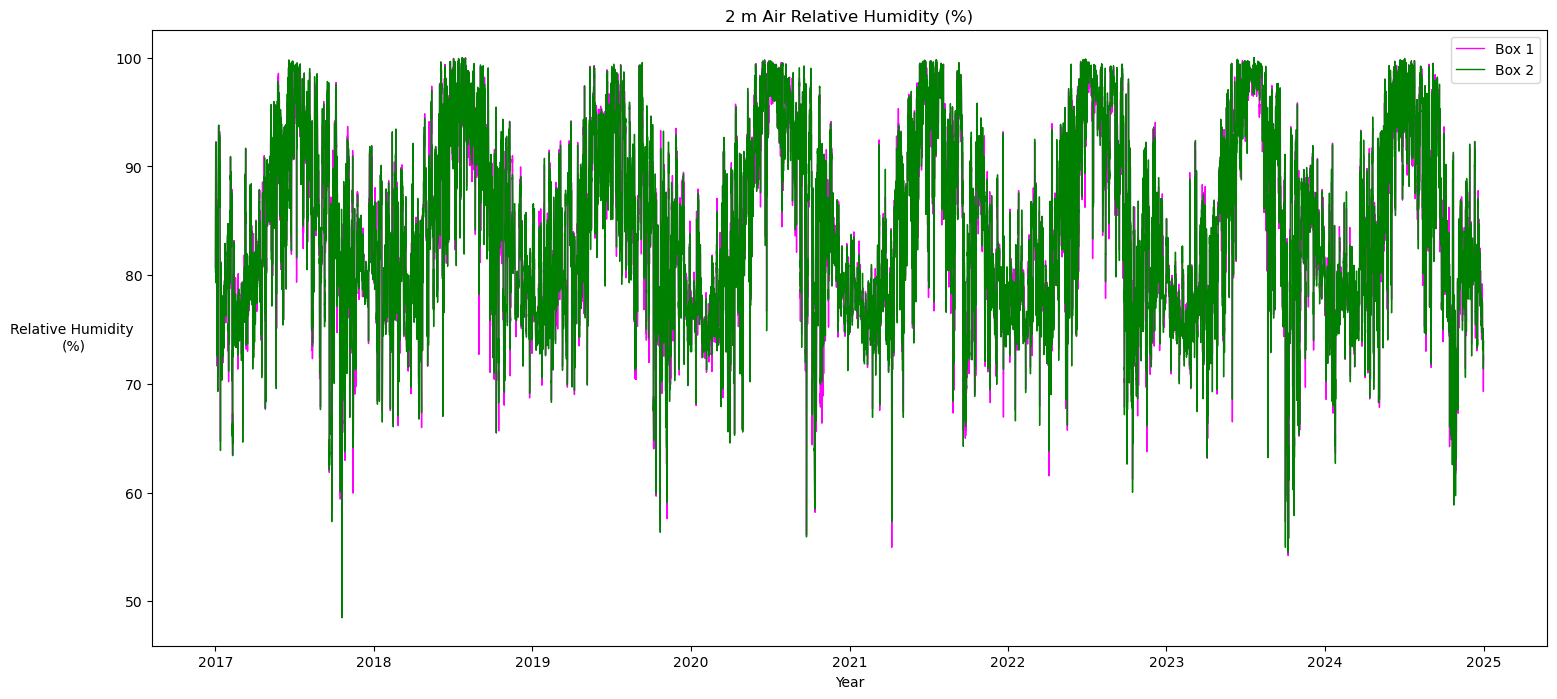

In [36]:
# Plot time series for these two regions (one panel for longwave
# and another for shortwave)

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(era5_air_temp.valid_time, air_rh_reg1_avg, color='magenta', linewidth=1, label='Box 1')
ax.plot(era5_air_temp.valid_time, air_rh_reg2_avg, color='green', linewidth=1, label='Box 2')
ax.set_title('2 m Air Relative Humidity (%)')
ax.set_ylabel('Relative Humidity \n(%)', rotation=0, va='center', labelpad=30)
ax.set_xlabel('Year')
ax.legend()

In [30]:
# Make a version of the plot that has the average value
# for each day of each based on all of these years

# group by hour of day of year to rpeserve that frequency

# Box 1
air_rh_reg1_avg_doy_hrly = air_rh_reg1_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')
# Box 2
air_rh_reg2_avg_doy_hrly = air_rh_reg2_avg.groupby(['valid_time.dayofyear', 'valid_time.hour']).mean('valid_time')

In [31]:
# Reshape to be time series
# Dumb way would be to loop and we could just do that...
# Yup takes no time do the dumb way
# Box 1 
air_rh_reg1_avg_doy_hrly2 = np.empty((len(air_rh_reg1_avg_doy_hrly[:,0])*len(air_rh_reg1_avg_doy_hrly[0,:])))
# Box 2
air_rh_reg2_avg_doy_hrly2 = np.empty((len(air_rh_reg2_avg_doy_hrly[:,0])*len(air_rh_reg2_avg_doy_hrly[0,:])))

# Set the count for looping
count = 0

# Loop through day of year
for d in range(len(air_temp_reg1_avg_doy_hrly[:,0])):
    # Set the indices 
    start = count
    end = start + 24
    #print('start: ', start)
    #print('end: ', end)
 
    # Save this to the array
    # Box 1
    air_rh_reg1_avg_doy_hrly2[start:end] = air_rh_reg1_avg_doy_hrly[d,:]
    # Box 2
    air_rh_reg2_avg_doy_hrly2[start:end] = air_rh_reg2_avg_doy_hrly[d,:]

    # Increase the count
    #print('count before: ', count)
    count = count + 24
    #print('count after: ', count)

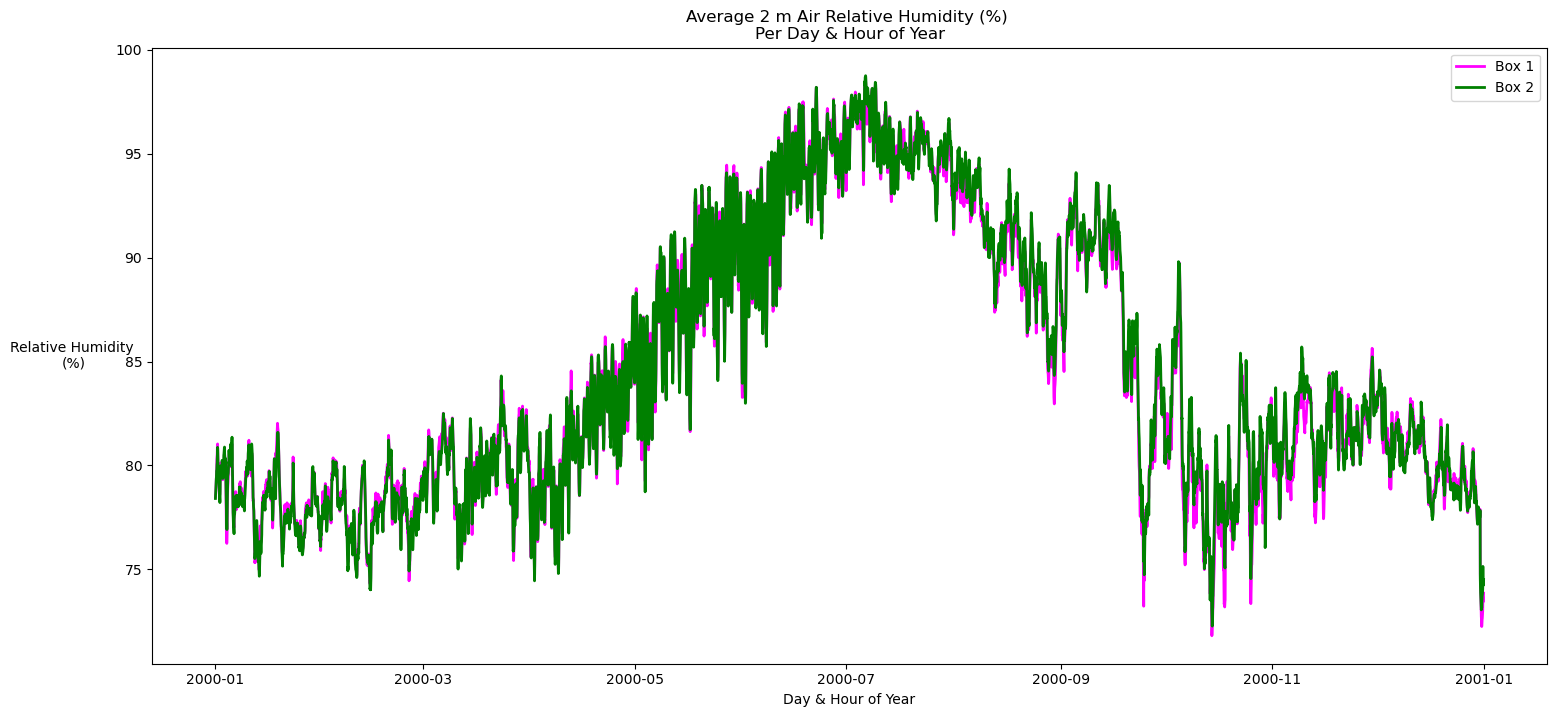

In [37]:
# Plot this

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes, air_rh_reg1_avg_doy_hrly2, color='magenta', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes, air_rh_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('Average 2 m Air Relative Humidity (%) \nPer Day & Hour of Year')
ax.set_ylabel('Relative Humidity \n(%)', rotation=0, va='center', labelpad=30)
ax.set_xlabel('Day & Hour of Year')
ax.legend()

Text(0.5, 0, 'Day & Hour of Year')

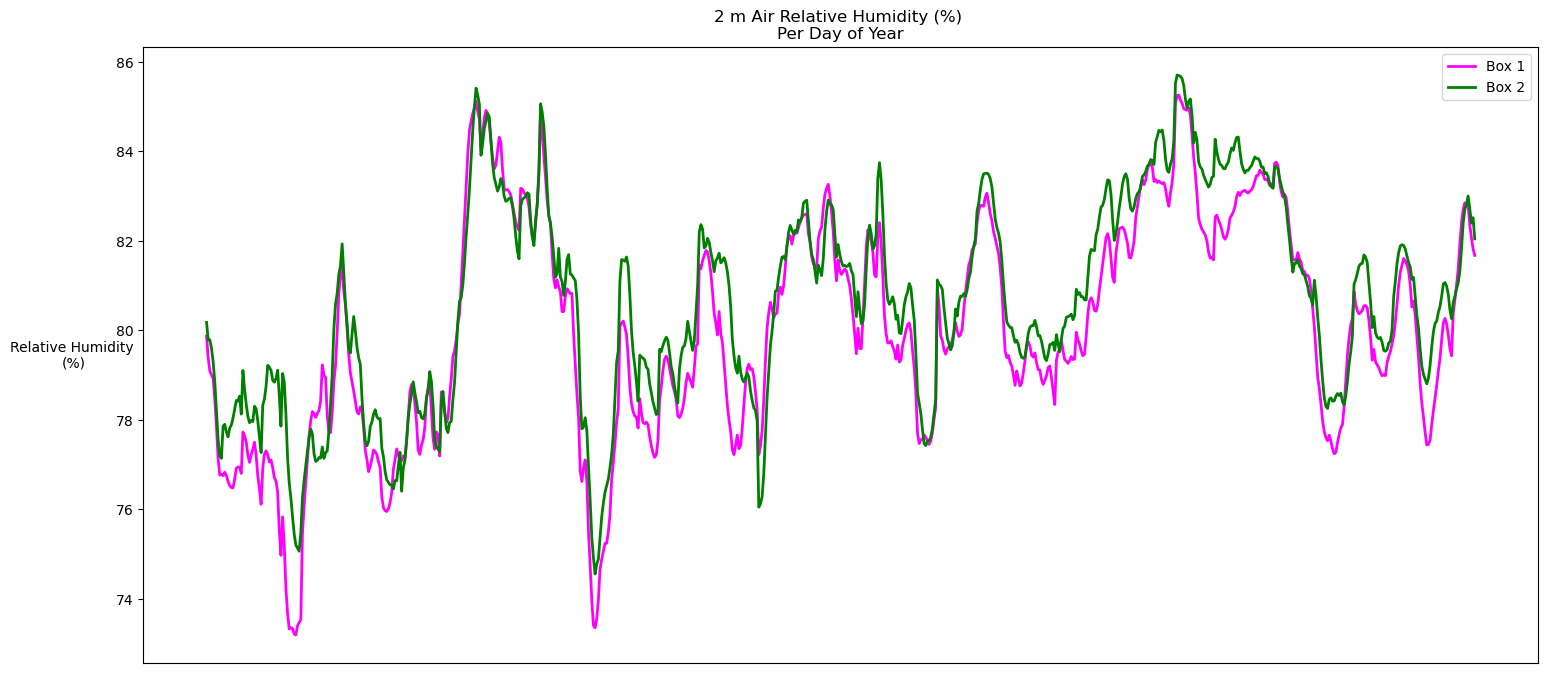

In [38]:
# Trim to just the period we want
# Plot the values around freeze-up which is mid-October to mid-November (ish)
# September 15 - October 15 = days 289 - 320 (leap year)

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes[289*24:321*24], air_rh_reg1_avg_doy_hrly2[289*24:321*24], color='magenta', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes[289*24:321*24], air_rh_reg2_avg_doy_hrly2[289*24:321*24], color='green', linewidth=2, label='Box 2')
ax.set_title('2 m Air Relative Humidity (%) \nPer Day of Year')
ax.set_ylabel('Relative Humidity \n(%)', rotation=0, va='center', labelpad=30)
ax.xaxis.set_visible(False)
ax.legend()
ax.set_xlabel('Day & Hour of Year')

In [39]:
# Now we can try to fit a sine curve to these data

In [41]:
# Before fitting a sine curve to this, shift the data
# to start in mid-October to make it easier for fitting

air_rh_reg1_avg_doy_hrly2_oct_start_pt1 = air_rh_reg1_avg_doy_hrly2[((289*24)+1):]
air_rh_reg1_avg_doy_hrly2_oct_start_pt2 = air_rh_reg1_avg_doy_hrly2[:((289*24)+1)]

# Now combine/append these two parts to get a ~9 month time series 
air_rh_reg1_avg_doy_hrly2_oct_start = np.concatenate((air_rh_reg1_avg_doy_hrly2_oct_start_pt1, air_rh_reg1_avg_doy_hrly2_oct_start_pt2))

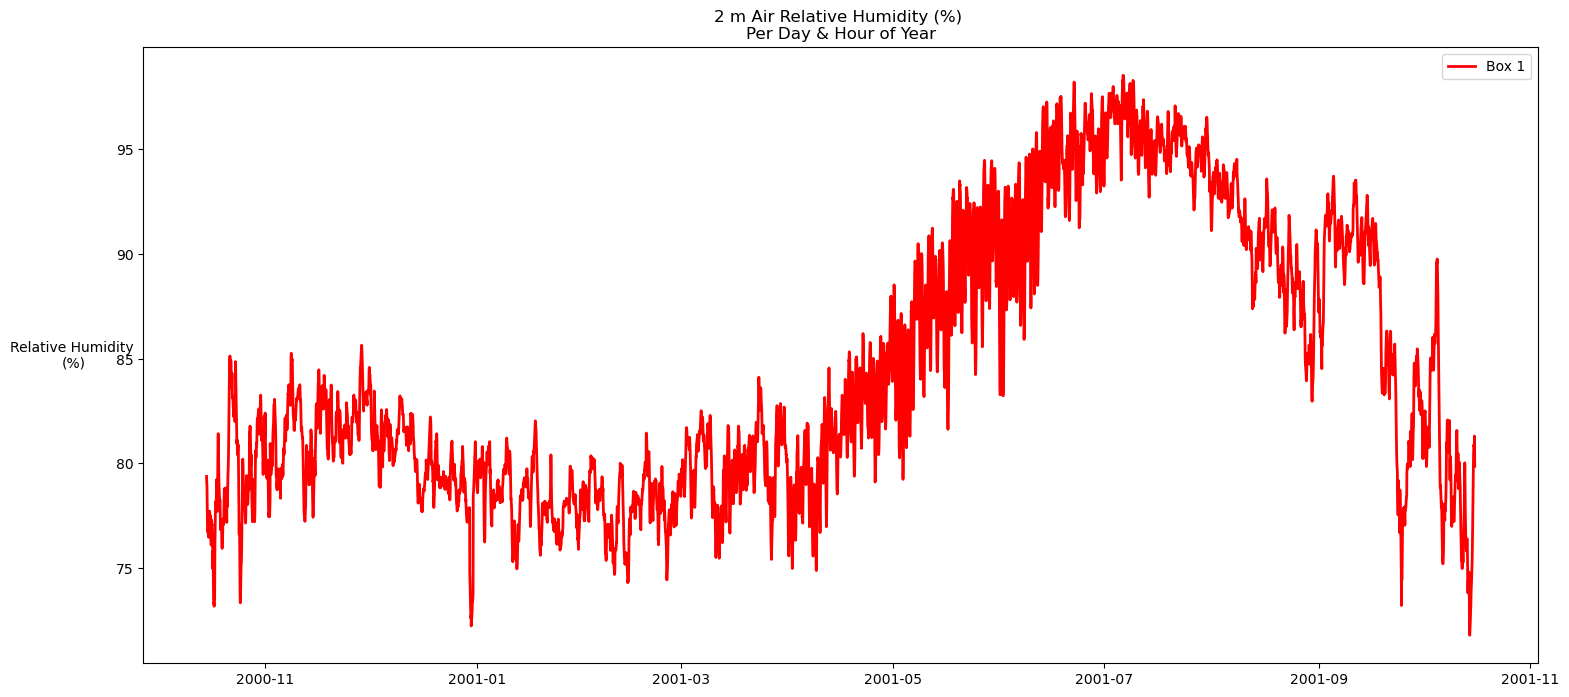

In [42]:
# Plot this to see how it looks

# Make shifted datetimes
hourly_datetimes_shifted = pd.date_range(start='2000-10-15', periods=366*24, freq='H')

# Plot the data
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes_shifted, air_rh_reg1_avg_doy_hrly2_oct_start, color='red', linewidth=2, label='Box 1')

#ax.plot(hourly_datetimes, longwave_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('2 m Air Relative Humidity (%) \nPer Day & Hour of Year')
ax.set_ylabel('Relative Humidity \n(%)', rotation=0, va='center', labelpad=30)
#ax.xaxis.set_visible(False)
ax.legend()

In [56]:
# For relative humidity, make a sine wave fit 
# to use for idealized version
# Work on a fit...
# Focus on Box 1 since that is the one we will base everything 
# else on
from scipy.optimize import curve_fit

# Define a function to make an inital guess of a sine wave
def sine_function(x, amplitude, frequency, phase, offset):
        return amplitude * np.sin(frequency * x + phase) + offset

# Initial guess for parameters (amplitude, frequency, phase, offset)
initial_guess = [10, (1/(366*24)), 0, 90]

# Convert time to hours since initial date to help with sine fit
time0 = hourly_datetimes[0]
numeric_time = (hourly_datetimes - time0) / np.timedelta64(1, 'h')

# Calculate/Fit parameters based on real data and the initial guess
params, covariance = curve_fit(sine_function, numeric_time, air_rh_reg1_avg_doy_hrly2_oct_start, p0=initial_guess)

# Pull out the parameters
amplitude_fit, frequency_fit, phase_fit, offset_fit = params

# Use these new parameters to make a new sine function that fits the data
y_fit = sine_function(numeric_time, amplitude_fit, frequency_fit, phase_fit, offset_fit)

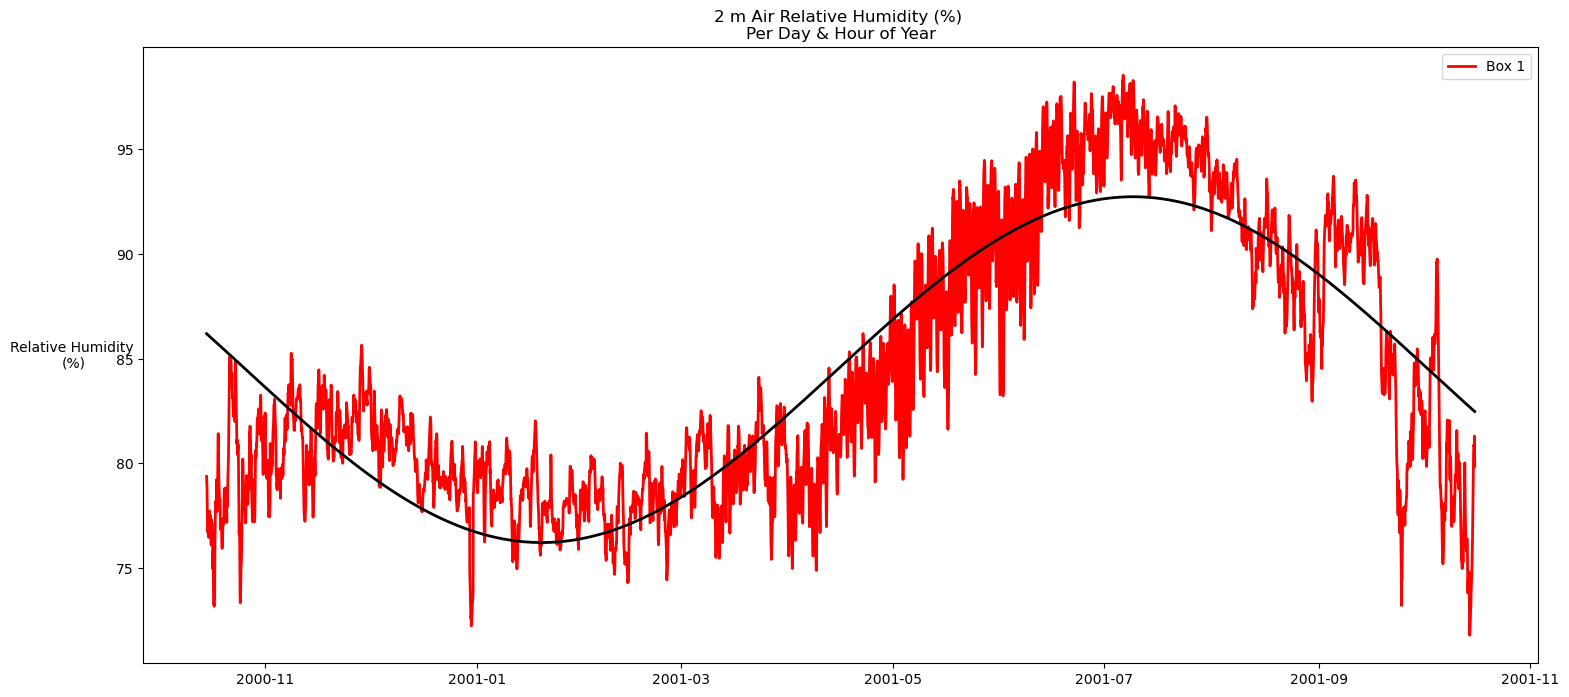

In [57]:
# Plot to see how this looks 

# Plot the data
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(hourly_datetimes_shifted, air_rh_reg1_avg_doy_hrly2_oct_start, color='red', linewidth=2, label='Box 1')
ax.plot(hourly_datetimes_shifted, y_fit, color='black', linewidth=2)

#ax.plot(hourly_datetimes, longwave_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('2 m Air Relative Humidity (%) \nPer Day & Hour of Year')
ax.set_ylabel('Relative Humidity \n(%)', rotation=0, va='center', labelpad=30)
#ax.xaxis.set_visible(False)
ax.legend()

In [58]:
# This is really not great but I think it is 
# close enough for now to see if this fixes noise things 
# or not soooo just go with it

In [59]:
# I don't really see big diurnal cycles in these plots 
# (ocean has large heat capacity...could be related) but 
# make version with diurnal cycle in case? Just to have?

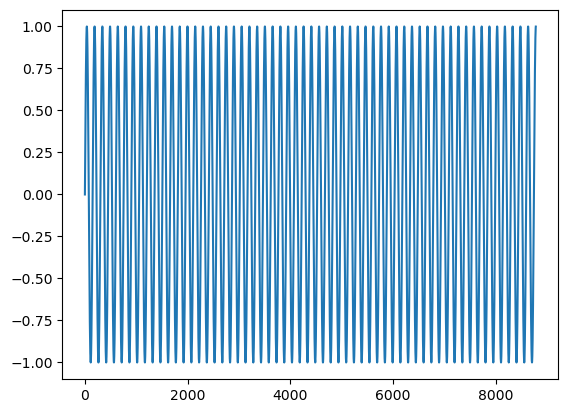

In [70]:
# Now take this curve and add daily variations of noise onto it
# Make a new sine wave that represents this wave and add them 
# together 
# You can adjust the amplitude of this "diurnal noise"
diurnal_amplitude = 1 # 2, 3

# def sine_function(x, amplitude, frequency, phase, offset):
#         return amplitude * np.sin(frequency * x + phase) + offset

# Make a curve from this 
diurnal_air_rh = diurnal_amplitude * np.sin((1/(24))*numeric_time)

# diurnal_noise = diurnal_amplitude * np.sin(2 * np.pi * 1 * numeric_time + np.random.uniform(0, 2*np.pi)) # Add slight phase randomization
plt.plot(diurnal_air_rh)

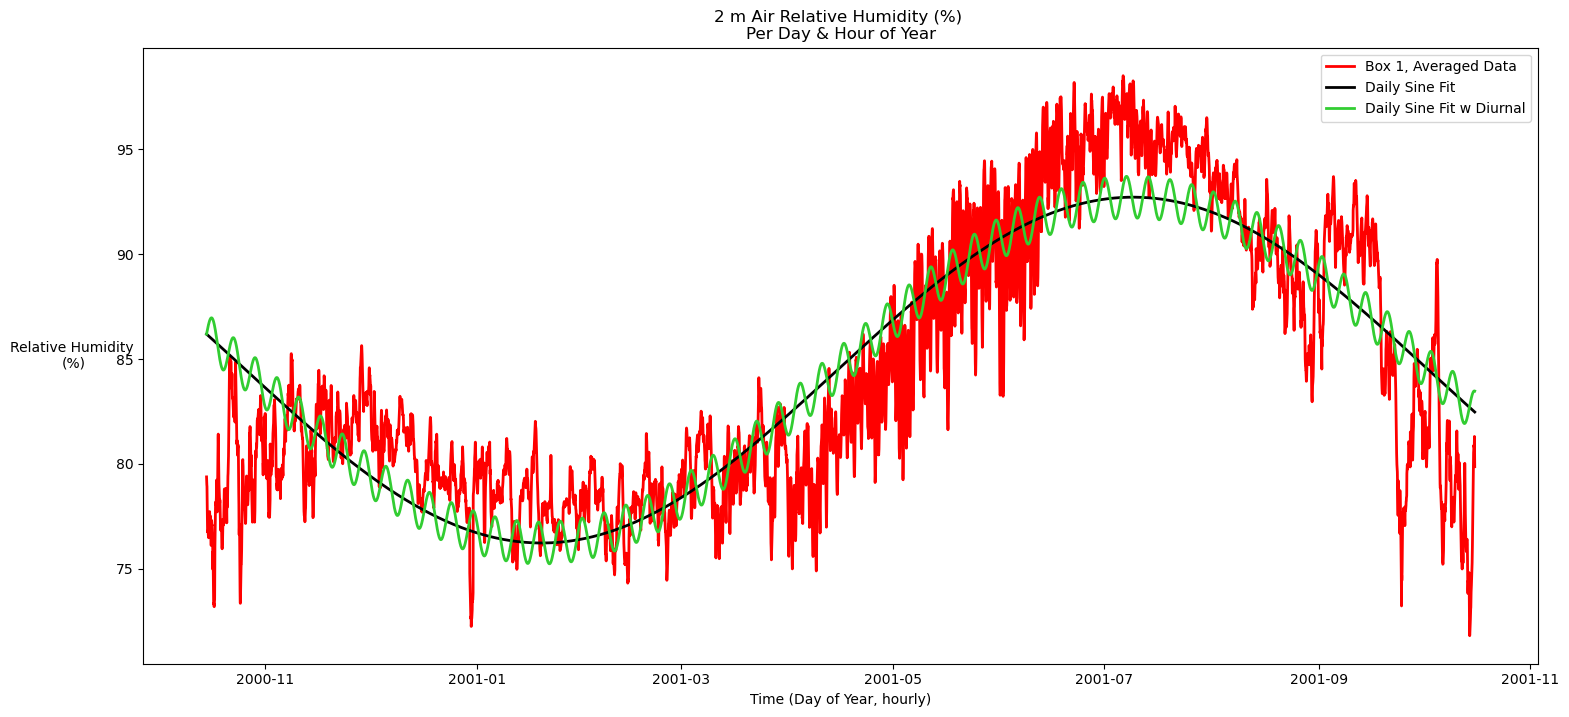

In [71]:
# NOw make a plot with these added together

# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Air temp
ax.plot(hourly_datetimes_shifted, air_rh_reg1_avg_doy_hrly2_oct_start, color='red', linewidth=2, label='Box 1, Averaged Data')
ax.plot(hourly_datetimes_shifted, y_fit, color='black', linewidth=2, label='Daily Sine Fit')
ax.plot(hourly_datetimes_shifted, y_fit+diurnal_air_rh, color='limegreen', linewidth=2, label='Daily Sine Fit w Diurnal')

#ax.plot(hourly_datetimes, longwave_reg2_avg_doy_hrly2, color='green', linewidth=2, label='Box 2')
ax.set_title('2 m Air Relative Humidity (%) \nPer Day & Hour of Year')
ax.set_ylabel('Relative Humidity \n(%)', rotation=0, va='center', labelpad=30)
ax.set_xlabel('Time (Day of Year, hourly)')
#ax.xaxis.set_visible(False)
ax.legend()

In [72]:
# Now pull out 9 months starting at October
# (shifted above so no need to shift here)
sine_fit_no_diurnal_reg1 = y_fit
idealized_air_rh_reg1 = sine_fit_no_diurnal_reg1[:((289*24)+1)]

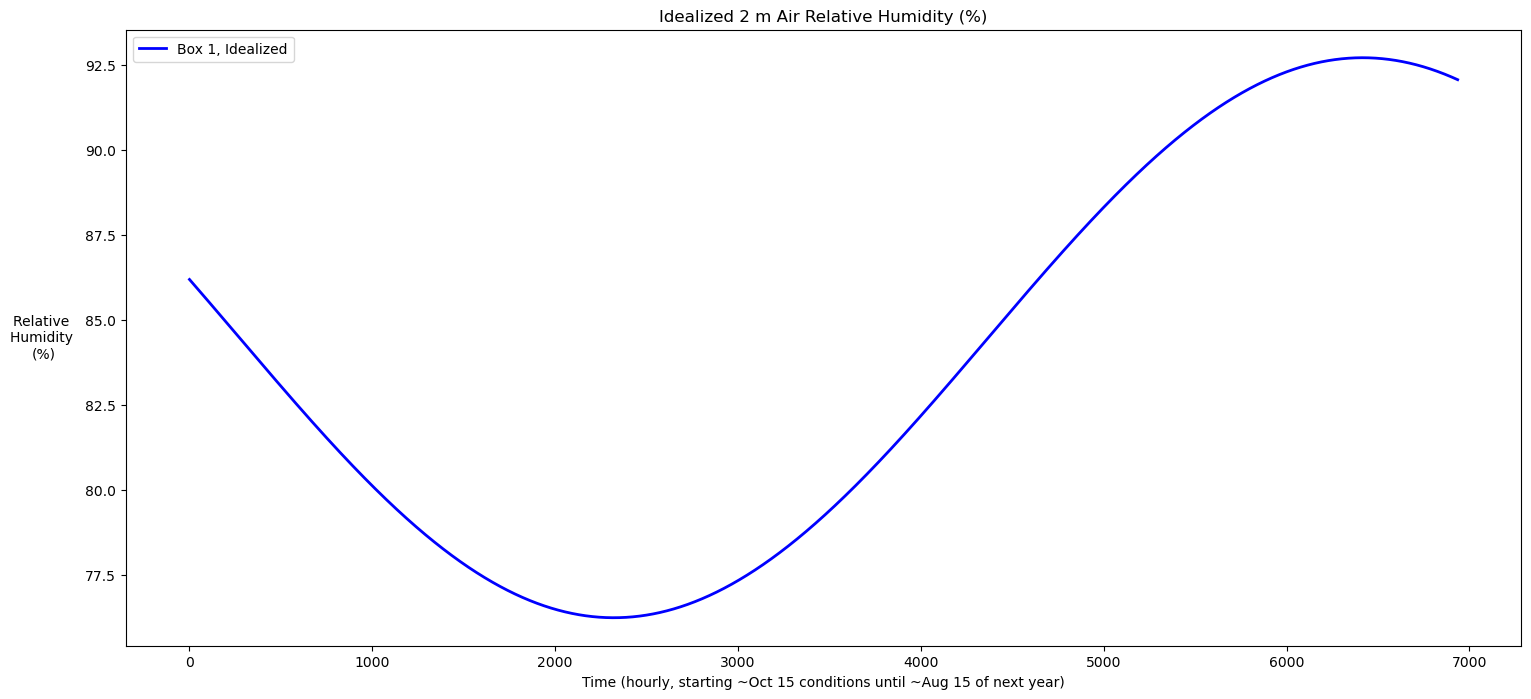

In [75]:
# Plot the idealized forcing 
# Make the figure
fig, ax = plt.subplots(figsize=(18,8))

# Longwave
ax.plot(idealized_air_rh_reg1, color='blue', linewidth=2, label='Box 1, Idealized')
ax.set_title('Idealized 2 m Air Relative Humidity (%)')
ax.set_ylabel('Relative \nHumidity \n(%)', rotation=0, va='center', labelpad=30)
ax.set_xlabel('Time (hourly, starting ~Oct 15 conditions until ~Aug 15 of next year)')
#ax.xaxis.set_visible(False)
ax.legend()

In [76]:
# Print the equation for the sine fit
print('Sine fit')
print('amplitude: ', amplitude_fit)
print('frequency: ', frequency_fit)
print('phase: ', phase_fit)
print('offsset: ', offset_fit)
#y_fit = sine_function(numeric_time, amplitude_fit, frequency_fit, phase_fit, offset_fit)

Sine fit
amplitude:  8.246570637003973
frequency:  0.0007671313143157416
phase:  -3.351235033863497
offsset:  84.47359372204187


### Set up the NetCDF  

The idealized model does not have any ties to lat/lon so the data can just be given in grid space rather than lat/lon and does not need to be interpolated or anything since it is spatially uniform. So we need to load the in the grid and then maybe remake this file any time you remake the grid.

In [77]:
# Load in the idealized model grid to get the dimensions 
# 500 m
#grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_500m_002.nc')
# 1 km
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1km_span_500km_noise_001.nc')

In [78]:
grid

<xarray.Dataset> Size: 12MB
Dimensions:      (eta_rho: 502, xi_rho: 202, eta_psi: 501, xi_psi: 201,
                  eta_u: 502, xi_u: 201, eta_v: 501, xi_v: 202)
Dimensions without coordinates: eta_rho, xi_rho, eta_psi, xi_psi, eta_u, xi_u,
                                eta_v, xi_v
Data variables: (12/18)
    x_rho        (eta_rho, xi_rho) float64 811kB ...
    y_rho        (eta_rho, xi_rho) float64 811kB ...
    x_psi        (eta_psi, xi_psi) float64 806kB ...
    y_psi        (eta_psi, xi_psi) float64 806kB ...
    x_u          (eta_u, xi_u) float64 807kB ...
    y_u          (eta_u, xi_u) float64 807kB ...
    ...           ...
    angle        (eta_rho, xi_rho) float64 811kB ...
    spherical    bool 1B ...
    xl           float64 8B ...
    el           float64 8B ...
    visc_factor  (eta_rho, xi_rho) float64 811kB ...
    diff_factor  (eta_rho, xi_rho) float64 811kB ...

In [79]:
# Pull out grid dimensions 
# Read in the dimensions
# rho
eta_rho_len = len(grid.eta_rho) # 206
xi_rho_len = len(grid.xi_rho) # 608
print('eta_rho_len: ', eta_rho_len)
print('xi_rho_len: ', xi_rho_len)
# u
eta_u_len = len(grid.eta_u) # 206
xi_u_len = len(grid.xi_u) # 607
print('eta_u_len: ', eta_u_len)
print('xi_u_len: ', xi_u_len)
# v
eta_v_len = len(grid.eta_v) #
xi_v_len = len(grid.xi_v) # 
print('eta_v_len: ', eta_v_len)
print('xi_v_len: ', xi_v_len)

# Define other dimension lengths
# eta rho
Mp = len(grid.eta_rho)
# xi rho
Lp = len(grid.xi_rho)
print('Mp: ', Mp)
print('Lp: ', Lp)

# # latitude
# lat_u_len = len(grid.lat_u)
# lat_v_len = len(grid.lat_v)
# print('lat_u_len: ', lat_u_len)
# print('lat_v_len: ', lat_v_len)

# # longitude
# lon_u_len = len(grid.lon_u)
# lon_v_len = len(grid.lon_v)
# print('lon_u_len: ', lon_u_len)
# print('lon_v_len: ', lon_v_len)

eta_rho_len:  502
xi_rho_len:  202
eta_u_len:  502
xi_u_len:  201
eta_v_len:  501
xi_v_len:  202
Mp:  502
Lp:  202


In [81]:
# Need to make a time that is hours since some reference time 
# Get the length of time for the data

# convert all the times to seconds since the first time step so it is on generic time)
#time_tmp = ((hourly_datetimes_shifted[:] - datetime(0,12,31)).total_seconds() - 86400)
time_tmp_1 = ((hourly_datetimes_shifted[:] - hourly_datetimes_shifted[0]).total_seconds())
# Trim to just the time we want
time_tmp = time_tmp_1[:len(idealized_air_rh_reg1)]
# Get the length from this 
# time
time_len = len(time_tmp)

In [82]:
time_tmp

Index([       0.0,     3600.0,     7200.0,    10800.0,    14400.0,    18000.0,
          21600.0,    25200.0,    28800.0,    32400.0,
       ...
       24937200.0, 24940800.0, 24944400.0, 24948000.0, 24951600.0, 24955200.0,
       24958800.0, 24962400.0, 24966000.0, 24969600.0],
      dtype='float64', length=6937)

In [83]:
print('len time_tmp: ', len(time_tmp))
print('len hourly_datetimes_shifted: ', len(hourly_datetimes_shifted))
print('len idealized_air_temp_reg1: ', len(idealized_air_rh_reg1))

len time_tmp:  6937
len hourly_datetimes_shifted:  8784
len idealized_air_temp_reg1:  6937


In [84]:
# Make a version of the code that is this shape and same everywhere
idealized_air_rh_reg1_ongrid = np.empty((time_len, eta_rho_len, xi_rho_len))

# Loop through space and fill with the idealized version
for y in range(eta_rho_len):
    for x in range(xi_rho_len):
        idealized_air_rh_reg1_ongrid[:,y,x] = idealized_air_rh_reg1

# Could insert a check for this at some point...

In [85]:
# No unit check since it is percentage so we should be good to go
print('max RH: ', np.max(idealized_air_rh_reg1))
print('min RH: ', np.min(idealized_air_rh_reg1))

max RH:  92.72016430274874
min RH:  76.22702310705513


In [86]:
# Make the netcdf for the forcing file 

# ------------------------------- Create the netCDF file ---------------------------

#name of file I am writing to
# 500 m
#tair_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Forcing_files/idealized_rh_forcing_500m_002.nc'   #UPDATE PATH
# 1 km
rh_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Forcing_files/idealized_rh_forcing_1km_span_500km_001.nc'   #UPDATE PATH

#create file to write to
nc1 = Dataset(rh_frc, 'w', format='NETCDF4')

#Global attributes
global_defaults = dict(gridname = '*.nc',
                      type = 'ROMS grid shaped ERA5 idealized air relative humidity forcing',
                      history = 'Created by Brianna Undzis',
                      Conventions = 'CF',
                      Institution = 'University of Colorado Boulder',
                      date = str(datetime.today()))
    
#create dictionary for model
d = {}
d = global_defaults

for att, value in d.items():
    setattr(nc1, att, value)

# Create dimensions
nc1.createDimension('xi_rho',  xi_rho_len)   # rho
nc1.createDimension('eta_rho', eta_rho_len)
# nc1.createDimension('lon',  era5_lon_len)   # rho
# nc1.createDimension('lat', era5_lat_len)
nc1.createDimension('qair_time', None)
nc1.createDimension('one',     1)

# Create variables 
# --------------------
# Coordinate Variables
# --------------------
# # era5 lon
# lon = nc1.createVariable('lon', 'd', ('lon',), zlib=True)
# lon.long_name = 'longitude coordinate of ERA5 data'
# lon.standard_name = 'projection_lon_coordinate'
# lon.units = 'degrees'
# lon_tmp = era5_longwave.longitude
# lon[:] = lon_tmp[:]

# # era5 lat
# lat = nc1.createVariable('lat', 'd', ('lat',), zlib=True)
# lat.long_name = 'latitude coordinate of ERA5 data'
# lat.standard_name = 'projection_lat_coordinate'
# lat.units = 'degrees'
# #lat_tmp = era5_longwave.latitude
# lat_tmp = lat_flip # FLIP
# lat[:] = lat_tmp[:]

# xi rho
xi_rho = nc1.createVariable('xi_rho', 'd', ('xi_rho',), zlib=True)
xi_rho.long_name = 'xi coordinate of RHO-points'
xi_rho.standard_name = 'projection_xi_coordinate'
xi_rho.units = 'meter'
xi_rho_tmp = np.arange(0, Lp)
xi_rho[:] = xi_rho_tmp[:]

# eta rho
eta_rho = nc1.createVariable('eta_rho', 'd', ('eta_rho',), zlib=True)
eta_rho.long_name = 'eta coordinate of RHO-points'
eta_rho.standard_name = 'projection_eta_coordinate'
eta_rho.units = 'meter'
eta_rho_tmp = np.arange(0, Mp)
eta_rho[:] = eta_rho_tmp[:]

# qair_time (in seconds)
qair_time_g = nc1.createVariable('qair_time', None, ('qair_time'), zlib=True)
qair_time_g.long_name = 'seconds since 0001-01-01 00:00:00' #with initialization of 2000-01-01 00:00:00
qair_time_g.units = 'second'
qair_time_g.field = 'time, scalar, series'
qair_time_g[:] = time_tmp[:]


# --------------------
# Atmospheric Variables 
# --------------------

# Qair
qair_interp_g = nc1.createVariable('Qair', 'f8', ('qair_time', 'eta_rho', 'xi_rho'), zlib=True, fill_value=1e30)
qair_interp_g.long_name = 'surface sir relative humidity'
qair_interp_g.standard_name = 'surface_air_relative_humidity'
qair_interp_g.units = 'percentage' 
qair_interp_g.coordinates = 'eta_rho xi_rho' 
qair_interp_g[:,:,:] = idealized_air_rh_reg1_ongrid[:,:,:]


nc1.close()
# ------------------------------- End netCDF ---------------------------